In [1]:
import pandas as pd
import os
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (recall_score, confusion_matrix, precision_recall_curve, average_precision_score, f1_score)
import time
import matplotlib.pyplot as plt

base_path = os.path.join(os.getcwd(), "..", "data")
processed_path = os.path.join(base_path, "processed")

mali_clean = pd.read_parquet(os.path.join(processed_path, "mali_clean.parquet"))
anom_clean = pd.read_parquet(os.path.join(processed_path, "anom_clean.parquet"))
norm_clean = pd.read_parquet(os.path.join(processed_path, "norm_clean.parquet"))

print(mali_clean.shape, anom_clean.shape, norm_clean.shape)

(19384, 39) (41400, 39) (51208, 39)


In [2]:
# Case-Level Metadaten aus Parquet extrahieren (eine Zeile pro Case)
all_data = pd.concat([mali_clean, anom_clean, norm_clean], ignore_index=True)
case_meta = (all_data
             .drop_duplicates(subset='case_id')[['case_id', 'scenario_id', 'dataset_type', 'label']]
             .reset_index(drop=True))

# Log-Text pro Case laden und aggregieren
def load_log_text(row):
    """Lädt den Syslog-Text einer .log-Datei anhand von dataset_type/scenario_id/case_id.
    Gibt leeren String zurück wenn Datei fehlt (kein Case wird verworfen)."""
    log_filename = row['case_id'].replace('.csv', '.log')
    log_path = os.path.join(base_path, f"{row['dataset_type']}_dataset",
                            row['scenario_id'], log_filename)
    if os.path.exists(log_path):
        with open(log_path, 'r', encoding='utf-8', errors='ignore') as f:
            return f.read()
    return ""

case_meta['log_text'] = case_meta.apply(load_log_text, axis=1)

missing = (case_meta['log_text'] == "").sum()
print(f"Cases gesamt:          {len(case_meta)}")
print(f"Cases mit Log-Text:    {(case_meta['log_text'] != '').sum()}")
print(f"Cases ohne Log-Datei:  {missing}")
print(f"\nLabel-Verteilung (Case-Ebene):\n{case_meta['label'].value_counts()}")

Cases gesamt:          1252
Cases mit Log-Text:    1252
Cases ohne Log-Datei:  0

Label-Verteilung (Case-Ebene):
label
0    1029
1     223
Name: count, dtype: int64


In [3]:
# ─── Splits aus NB02 laden ────────────────────────────────────────────────────
# Dieselbe Split-Zuordnung wie NB02 — kein eigenständiger GSS-Aufruf.
# Verhindert Inkonsistenz zwischen NB02 und NB03.
docs_path = os.path.join(os.getcwd(), "..", "docs")
split_df = pd.read_csv(os.path.join(docs_path, "split_assignments.csv"))

train_ids = set(split_df[split_df['split'] == 'train']['case_id'])
val_ids   = set(split_df[split_df['split'] == 'val']['case_id'])
test_ids  = set(split_df[split_df['split'] == 'test']['case_id'])

case_meta['group_id'] = case_meta['dataset_type'] + '_' + case_meta['scenario_id'].astype(str)

train_cases_df = case_meta[case_meta['case_id'].isin(train_ids)].reset_index(drop=True)
val_cases_df   = case_meta[case_meta['case_id'].isin(val_ids)].reset_index(drop=True)
test_cases_df  = case_meta[case_meta['case_id'].isin(test_ids)].reset_index(drop=True)

X_train_text = train_cases_df['log_text']
X_val_text   = val_cases_df['log_text']
X_test_text  = test_cases_df['log_text']
y_train_case = train_cases_df['label']
y_val_case   = val_cases_df['label']
y_test_case  = test_cases_df['label']

neg = (y_train_case == 0).sum()
pos = (y_train_case == 1).sum()

print(f"Train: {len(train_cases_df)} Cases | Val: {len(val_cases_df)} Cases | Test: {len(test_cases_df)} Cases")
print(f"Train pos={pos}, neg={neg} → Ratio: {neg/pos:.2f}")
print(f"Val   pos={int(y_val_case.sum())}, neg={int((y_val_case==0).sum())}")
print(f"Test  dataset breakdown:\n{test_cases_df['dataset_type'].value_counts()}")

Train: 793 Cases | Val: 206 Cases | Test: 253 Cases
Train pos=122, neg=671 → Ratio: 5.50
Val   pos=53, neg=153
Test  dataset breakdown:
dataset_type
norm    129
anom     76
mali     48
Name: count, dtype: int64


In [4]:
# TF-IDF: fit nur auf Trainingsdaten (kein Leakage auf Val oder Test)
vectorizer = TfidfVectorizer(
    max_features=10_000,    # Kompromiss: ausreichend Vokabular, sparse Matrix handhabbar
    ngram_range=(1, 2),     # Bigramme essentiell für Syslog: 'msg audit', 'password for'
    sublinear_tf=True,      # log(tf) statt tf — robuster bei langen Logs mit Wiederholungen
    min_df=2,               # Term muss in ≥2 Cases vorkommen — verhindert Overfitting
    analyzer='word'
)

X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_val_tfidf   = vectorizer.transform(X_val_text)   # Val: nur transform (kein fit)
X_test_tfidf  = vectorizer.transform(X_test_text)  # Test: nur transform (kein fit)

print(f"Vokabular-Größe:  {len(vectorizer.vocabulary_)}")
print(f"Train Matrix:     {X_train_tfidf.shape}")
print(f"Val Matrix:       {X_val_tfidf.shape}")
print(f"Test Matrix:      {X_test_tfidf.shape}")

Vokabular-Größe:  10000
Train Matrix:     (793, 10000)
Val Matrix:       (206, 10000)
Test Matrix:      (253, 10000)


In [5]:
log_reg = LogisticRegression(
    class_weight='balanced',  # Kompensiert 1:4.71-Ungleichgewicht im Trainingsset
    max_iter=1000,            # Erhöht für Konvergenz auf 10k-dimensionaler TF-IDF Matrix
    random_state=42,
    solver='lbfgs',           # Effizient auf sparse hochdimensionalen Matrizen
    C=1.0                     # Standard-Regularisierung; kein Tuning nötig für Baseline
)

log_reg.fit(X_train_tfidf, y_train_case)
print("Training abgeschlossen.")
print(f"Klassen: {log_reg.classes_}")

Training abgeschlossen.
Klassen: [0 1]


In [6]:
# ─── Threshold-Wahl auf Validierungsset ──────────────────────────────────────
# Testset wird hier nicht berührt.
y_proba_val_log = log_reg.predict_proba(X_val_tfidf)[:, 1]
precisions_val_log, recalls_val_log, thresholds_val_log = precision_recall_curve(y_val_case, y_proba_val_log)
ap_val_log = average_precision_score(y_val_case, y_proba_val_log)

valid_thr_val_log = thresholds_val_log[recalls_val_log[:-1] >= 0.95]
best_threshold_log_val = float(valid_thr_val_log.max()) if len(valid_thr_val_log) > 0 else float(thresholds_val_log[0])

print(f"Validation AP:               {ap_val_log:.4f}")
print(f"Threshold (Val, Rec≥0.95):   {best_threshold_log_val:.4f}")
print(f"Val-Recall @ Threshold:      {recall_score(y_val_case, (y_proba_val_log >= best_threshold_log_val).astype(int)):.4f}")

# ─── Finale Evaluation ausschließlich auf Testset ─────────────────────────────
t0 = time.time()
y_proba_test_log = log_reg.predict_proba(X_test_tfidf)[:, 1]
latency_ms = (time.time() - t0) * 1000

precisions_test_log, recalls_test_log, thresholds_test_log = precision_recall_curve(y_test_case, y_proba_test_log)
ap_test_log = average_precision_score(y_test_case, y_proba_test_log)

# Wende eingefrorenen Val-Threshold auf Test an
y_pred_test_log = (y_proba_test_log >= best_threshold_log_val).astype(int)
tn_log, fp_log, fn_log, tp_log = confusion_matrix(y_test_case, y_pred_test_log).ravel()
precision_at_t_log = tp_log / (tp_log + fp_log) if (tp_log + fp_log) > 0 else 0

print(f"\n=== Finale Test-Evaluation (Threshold aus Validation) ===")
print(f"Average Precision (AP):      {ap_test_log:.4f}")
print(f"Threshold (aus Val):         {best_threshold_log_val:.4f}")
print(f"Test-Recall @ Threshold:     {recall_score(y_test_case, y_pred_test_log):.4f}")
print(f"Test-Precision:              {precision_at_t_log:.4f}")
print(f"Test-F1:                     {f1_score(y_test_case, y_pred_test_log):.4f}")
print(f"Test-Latenz:                 {latency_ms:.1f} ms  ({X_test_tfidf.shape[0]} Cases, indikativ)")
print(f"Test-FPR (Case-Ebene):       {fp_log / (fp_log + tn_log):.4f}  ({fp_log} FP von {fp_log+tn_log})")

# ─── Audit-Artefakt: log_test_scores.csv ─────────────────────────────────────
docs_path = os.path.join(os.getcwd(), "..", "docs")
os.makedirs(docs_path, exist_ok=True)
log_scores_df = test_cases_df[['case_id', 'dataset_type', 'scenario_id', 'group_id', 'label']].copy()
log_scores_df['log_score']         = y_proba_test_log
log_scores_df['log_pred']          = y_pred_test_log
log_scores_df['threshold_log_val'] = best_threshold_log_val
log_scores_df.to_csv(os.path.join(docs_path, "log_test_scores.csv"), index=False)
print(f"\n✓ log_test_scores.csv gespeichert ({len(log_scores_df)} Cases)")

# ─── Validierungsset-Scores speichern (für Threshold-Sensitivity-Analyse) ──────
log_val_scores_df = val_cases_df[['case_id', 'dataset_type', 'scenario_id', 'group_id', 'label']].copy()
log_val_scores_df['log_score'] = y_proba_val_log
log_val_scores_df.to_csv(os.path.join(docs_path, "log_val_scores.csv"), index=False)
print(f"✓ log_val_scores.csv gespeichert ({len(log_val_scores_df)} Cases)")

Validation AP:               0.9104
Threshold (Val, Rec≥0.95):   0.2300
Val-Recall @ Threshold:      0.9623

=== Finale Test-Evaluation (Threshold aus Validation) ===
Average Precision (AP):      0.7108
Threshold (aus Val):         0.2300
Test-Recall @ Threshold:     0.9375
Test-Precision:              0.5000
Test-F1:                     0.6522
Test-Latenz:                 0.0 ms  (253 Cases, indikativ)
Test-FPR (Case-Ebene):       0.2195  (45 FP von 205)

✓ log_test_scores.csv gespeichert (253 Cases)
✓ log_val_scores.csv gespeichert (206 Cases)


In [7]:
# ─── Threshold-Sensitivity-Analyse: Log-Komponente (Val-basiert) ──────────────
# Für jedes Recall-Ziel: höchsten Val-Threshold bestimmen → auf Test anwenden.
# METHODISCH KORREKT: Threshold-Wahl ausschließlich anhand Validation-Scores.
# Testmetriken sind reine Auswertung — kein Auswahlkriterium.
from sklearn.metrics import precision_score  # ergänzt für Sensitivity-Analyse

RECALL_TARGETS = [0.95, 0.975, 0.99, 1.00]

rows = []
for target in RECALL_TARGETS:
    # Höchsten Val-Threshold, der target-Recall erfüllt
    valid = thresholds_val_log[recalls_val_log[:-1] >= target]
    if len(valid) > 0:
        thr = float(valid.max())
    else:
        # Fallback: niedrigster Threshold → sichert maximales Recall
        thr = float(thresholds_val_log[0])

    val_rec = float(recall_score(y_val_case, (y_proba_val_log >= thr).astype(int)))

    # Test-Metriken (nur Auswertung)
    y_pred_s = (y_proba_test_log >= thr).astype(int)
    tn_s, fp_s, fn_s, tp_s = confusion_matrix(y_test_case, y_pred_s).ravel()
    fpr_s   = round(fp_s / (fp_s + tn_s), 4) if (fp_s + tn_s) > 0 else 0
    prec_s  = round(precision_score(y_test_case, y_pred_s, zero_division=0), 4)
    rec_s   = round(recall_score(y_test_case, y_pred_s), 4)
    f1_s    = round(f1_score(y_test_case, y_pred_s, zero_division=0), 4)

    rows.append({
        'target_recall_val': target,
        'threshold_val':     round(thr, 6),
        'val_recall':        round(val_rec, 4),
        'test_recall':       rec_s,
        'test_fpr':          fpr_s,
        'test_precision':    prec_s,
        'test_f1':           f1_s,
        'TP': int(tp_s), 'FP': int(fp_s), 'TN': int(tn_s), 'FN': int(fn_s)
    })

sensitivity_df = pd.DataFrame(rows)
sensitivity_df.to_csv(os.path.join(docs_path, "threshold_sensitivity_log.csv"), index=False)
print("=== Log-Threshold-Sensitivity (Val-basiert) ===")
print(sensitivity_df.to_string(index=False))
print(f"\n✓ threshold_sensitivity_log.csv gespeichert")

=== Log-Threshold-Sensitivity (Val-basiert) ===
 target_recall_val  threshold_val  val_recall  test_recall  test_fpr  test_precision  test_f1  TP  FP  TN  FN
             0.950       0.230019      0.9623       0.9375    0.2195            0.50   0.6522  45  45 160   3
             0.975       0.134152      1.0000       0.9375    0.3902            0.36   0.5202  45  80 125   3
             0.990       0.134152      1.0000       0.9375    0.3902            0.36   0.5202  45  80 125   3
             1.000       0.134152      1.0000       0.9375    0.3902            0.36   0.5202  45  80 125   3

✓ threshold_sensitivity_log.csv gespeichert


In [8]:
# FPR getrennt nach Dataset-Typ: prüft ob Log-Validator zwischen
# technischen Anomalien (anom) und täuschend normalen Szenarien (norm) unterscheidet
for dtype in ['anom', 'norm']:
    mask = (test_cases_df['dataset_type'] == dtype).values
    fp_sub = y_pred_test_log[mask].sum()
    total_sub = mask.sum()
    print(f"FPR {dtype}: {fp_sub/total_sub:.4f}  ({fp_sub} FP von {total_sub})")

FPR anom: 0.1842  (14 FP von 76)
FPR norm: 0.2403  (31 FP von 129)


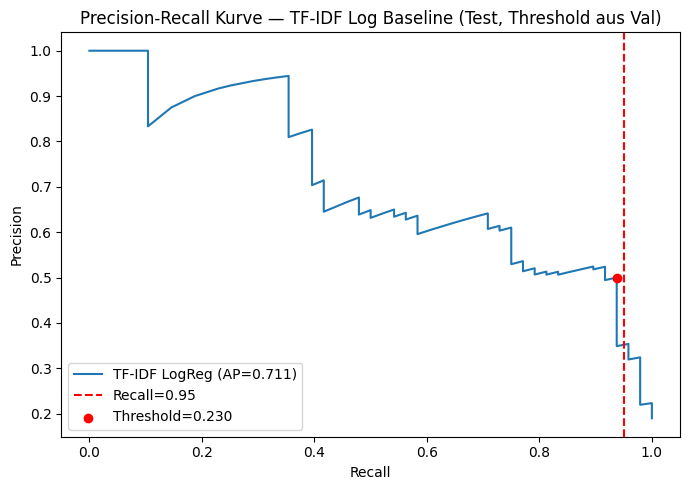

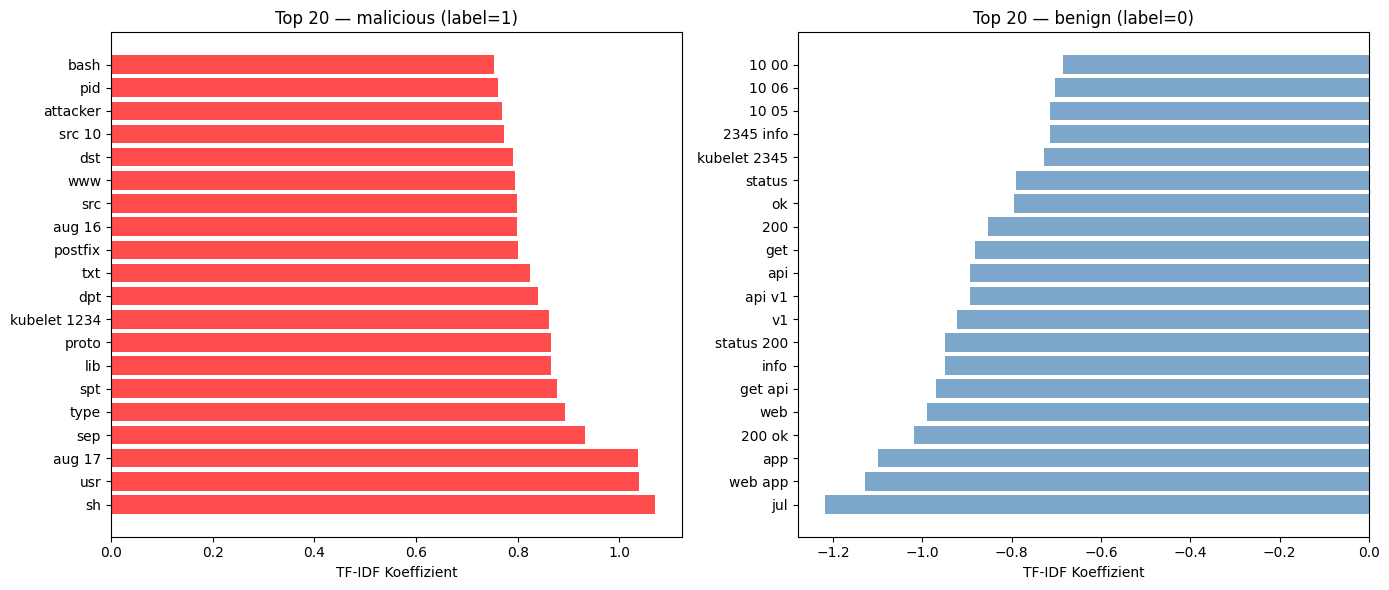

Plots gespeichert.


In [9]:
docs_path = os.path.join(os.getcwd(), "..", "docs")
os.makedirs(docs_path, exist_ok=True)

# PR-Kurve
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recalls_test_log, precisions_test_log, label=f'TF-IDF LogReg (AP={ap_test_log:.3f})')
ax.axvline(x=0.95, color='red', linestyle='--', label='Recall=0.95')
ax.scatter([recall_score(y_test_case, y_pred_test_log)],
           [precision_at_t_log],
           color='red', zorder=5, label=f'Threshold={best_threshold_log_val:.3f}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Kurve — TF-IDF Log Baseline (Test, Threshold aus Val)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(docs_path, "pr_curve_log.png"), dpi=150)
plt.show()

# Top TF-IDF Features nach Koeffizient
feature_names = vectorizer.get_feature_names_out()
coefs = log_reg.coef_[0]

# Koeffizienten absteigend sortiert: höchste = stärkste malicious-Indikatoren
top_pos_idx = coefs.argsort()[-20:][::-1]
# Aufsteigend sortiert: negativste = stärkste benign-Indikatoren
top_neg_idx = coefs.argsort()[:20]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh([feature_names[i] for i in top_pos_idx],
             coefs[top_pos_idx], color='red', alpha=0.7)
axes[0].set_title("Top 20 — malicious (label=1)")
axes[0].set_xlabel("TF-IDF Koeffizient")
axes[1].barh([feature_names[i] for i in top_neg_idx],
             coefs[top_neg_idx], color='steelblue', alpha=0.7)
axes[1].set_title("Top 20 — benign (label=0)")
axes[1].set_xlabel("TF-IDF Koeffizient")
plt.tight_layout()
plt.savefig(os.path.join(docs_path, "tfidf_top_features.png"), dpi=150)
plt.show()
print("Plots gespeichert.")